# Repair Results Analysis

This notebook loads repair results from SQLite databases and generates summary statistics and visualizations.


In [1]:
import os
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
%matplotlib inline

In [3]:
database_version = "14"

In [4]:
target_db = f'targets{database_version}.db'

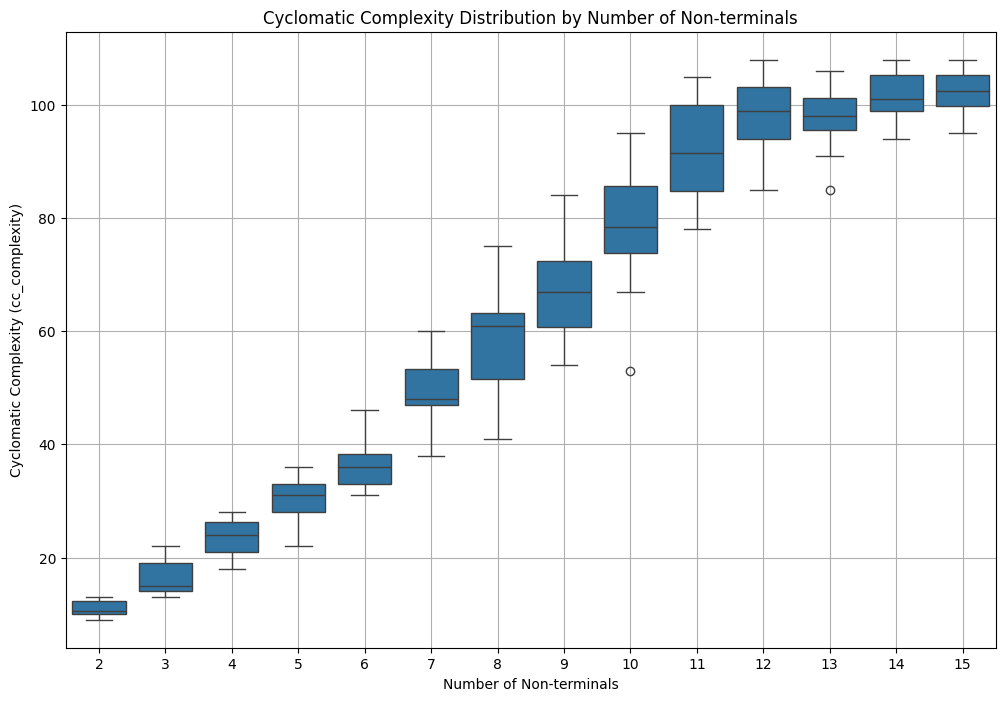

In [5]:
db_file = f'targets{database_version}.db'
conn = sqlite3.connect(db_file)

# Query the data
query = "SELECT num_nonterminals, cc_complexity FROM cases WHERE cc_complexity IS NOT NULL"
df = pd.read_sql_query(query, conn)

# Close the connection
conn.close()

# Create the plot
plt.figure(figsize=(12, 8))
sns.boxplot(x='num_nonterminals', y='cc_complexity', data=df)

# Set titles and labels
plt.title('Cyclomatic Complexity Distribution by Number of Non-terminals')
plt.xlabel('Number of Non-terminals')
plt.ylabel('Cyclomatic Complexity (cc_complexity)')
plt.grid(True)
plt.show()

In [6]:
sources_dbs = [
            "repair_results_openai_gpt-4.1-2025-04-14_targets14.db",
            # "repair_results_gemini_gemini-2.5-flash_targets14.db",
            "repair_results_ollama_llama3:70b_targets14.db",
            "repair_results_openai_o4-mini-2025-04-16_targets14.db"
            ]

In [7]:
import sqlite3
conn = sqlite3.connect(target_db)
# Note: cases.id in targets DB corresponds to source puzzle.id
df_cases = pd.read_sql(
    "SELECT id AS puzzle_id, num_nonterminals, nonterminal_prob, loop_prob, mutation_depth, original_parser, corrupted_grammar FROM cases",
    conn
)

# Compute derived columns for analysis
df_cases['parser_size'] = df_cases['original_parser'].str.len()
df_cases['corrupted_symbol_count'] = df_cases['corrupted_grammar'].str.split().str.len()

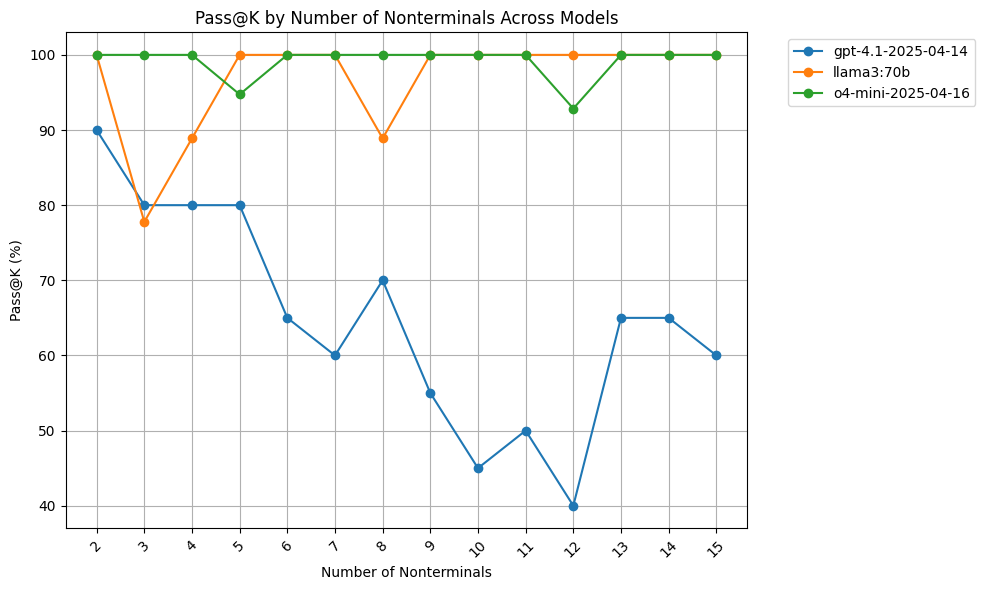

In [8]:
# Compute Pass@K by number of nonterminals across models
records = []
for db_path in sources_dbs:
    model = os.path.basename(db_path).removeprefix('repair_results_').removesuffix(f'_targets{database_version}.db').split('_')[1]
    conn = sqlite3.connect(db_path)
    df_res = pd.read_sql('SELECT case_id, correct FROM repair_results', conn)
    conn.close()
    df_passk = df_res.groupby('case_id', as_index=False)['correct'].any()
    df_passk.rename(columns={'correct': 'solved'}, inplace=True)
    df_merge = df_cases[['puzzle_id','num_nonterminals']].merge(
        df_passk, left_on='puzzle_id', right_on='case_id'
    )
    total_counts = df_merge.groupby('num_nonterminals')['case_id'].nunique().to_dict()
    solved_counts = (
        df_merge[df_merge['solved']]
            .groupby('num_nonterminals')['case_id']
            .nunique()
            .to_dict()
    )
    for num_nt in range(2,16):
        solved = solved_counts.get(num_nt, 0)
        total = total_counts.get(num_nt, 0)
        rate = solved / total * 100 if total > 0 else 0
        records.append({ 'model': model, 'num_nonterminals': num_nt, 'pass_rate': rate })
df_rates = pd.DataFrame(records)

plt.figure(figsize=(10,6))
for model in sorted(df_rates['model'].unique()):
    df_m = df_rates[df_rates['model']==model].sort_values('num_nonterminals')
    plt.plot(df_m['num_nonterminals'], df_m['pass_rate'], marker='o', label=model)

plt.xlabel('Number of Nonterminals')
plt.ylabel('Pass@K (%)')
plt.title('Pass@K by Number of Nonterminals Across Models')
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.xticks(range(2, 16), rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


/var/folders/4p/mcvjxqjj0f32176nf_3wv1gc0000gt/T/ipykernel_40172/1067333897.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_okcases, x='model', y='corrupted_symbol_count', palette='tab10')


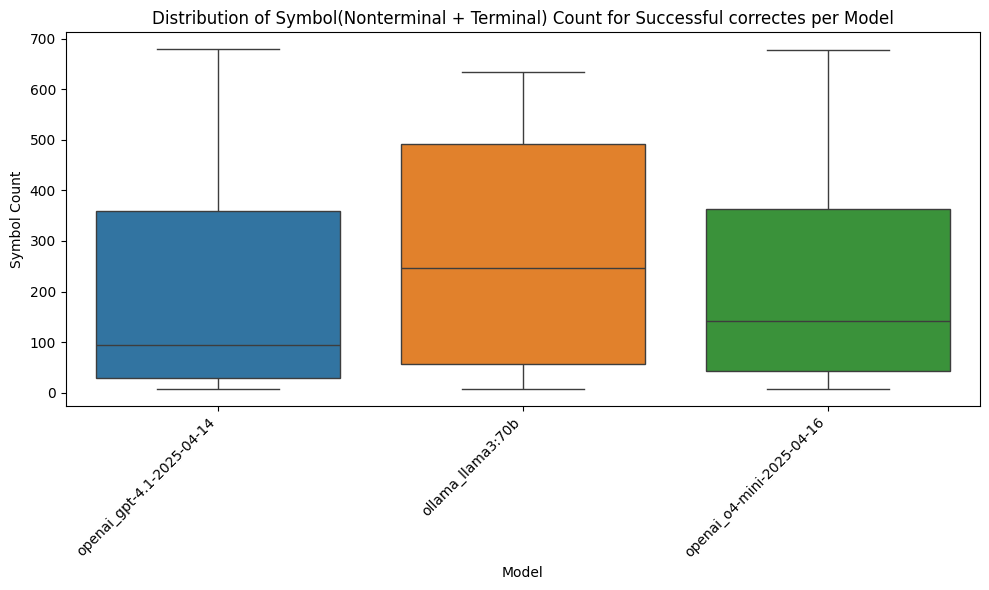

In [9]:
# Distribution of corrupted_symbol_count for successful correctes per model
records = []
for db_path in sources_dbs:
    model = os.path.basename(db_path).removeprefix('repair_results_').removesuffix(f'_targets{database_version}.db')
    conn = sqlite3.connect(db_path)
    df_res = pd.read_sql(
        'SELECT case_id, correct FROM repair_results',
        conn
    )
    conn.close()
    df_ok = df_res[df_res['correct'] == 1].merge(
        df_cases[['puzzle_id', 'corrupted_symbol_count']], left_on='case_id', right_on='puzzle_id'
    )
    for cs in df_ok['corrupted_symbol_count']:
        records.append({'model': model, 'corrupted_symbol_count': cs})

df_okcases = pd.DataFrame(records)

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_okcases, x='model', y='corrupted_symbol_count', palette='tab10')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Model')
plt.ylabel('Symbol Count')
plt.title('Distribution of Symbol(Nonterminal + Terminal) Count for Successful correctes per Model')
plt.tight_layout()


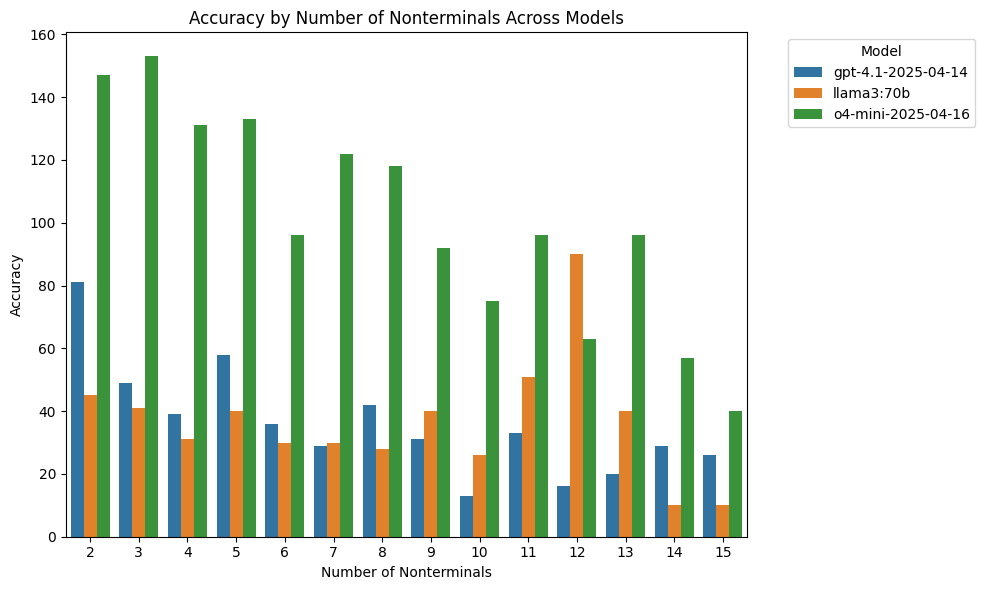

In [10]:
# Bar plot of accuracy by number of nonterminals across all models
# Ensure num_nonterminals is integer for correct sorting and plotting
df_cases['num_nonterminals'] = pd.to_numeric(df_cases['num_nonterminals'], errors='coerce')
df_cases = df_cases.dropna(subset=['num_nonterminals'])
df_cases['num_nonterminals'] = df_cases['num_nonterminals'].astype(int)

records = []
for db_path in sources_dbs:
    model = os.path.basename(db_path).removeprefix('repair_results_').removesuffix(f'_targets{database_version}.db').split('_')[1]
    conn = sqlite3.connect(db_path)
    df_res = pd.read_sql('SELECT case_id, correct FROM repair_results', conn)
    conn.close()
    df_ok = df_res[df_res['correct'] == 1].merge(df_cases[['puzzle_id','num_nonterminals']], left_on='case_id', right_on='puzzle_id')
    counts = df_ok['num_nonterminals'].value_counts().sort_index()
    for num_nt, cnt in counts.items():
        records.append({'model': model, 'num_nonterminals': num_nt, 'accuracy': cnt})

df_nt_correctes = pd.DataFrame(records)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_nt_correctes, x='num_nonterminals', y='accuracy', hue='model')
plt.xlabel('Number of Nonterminals')
plt.ylabel('Accuracy')
plt.title('Accuracy by Number of Nonterminals Across Models')
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()


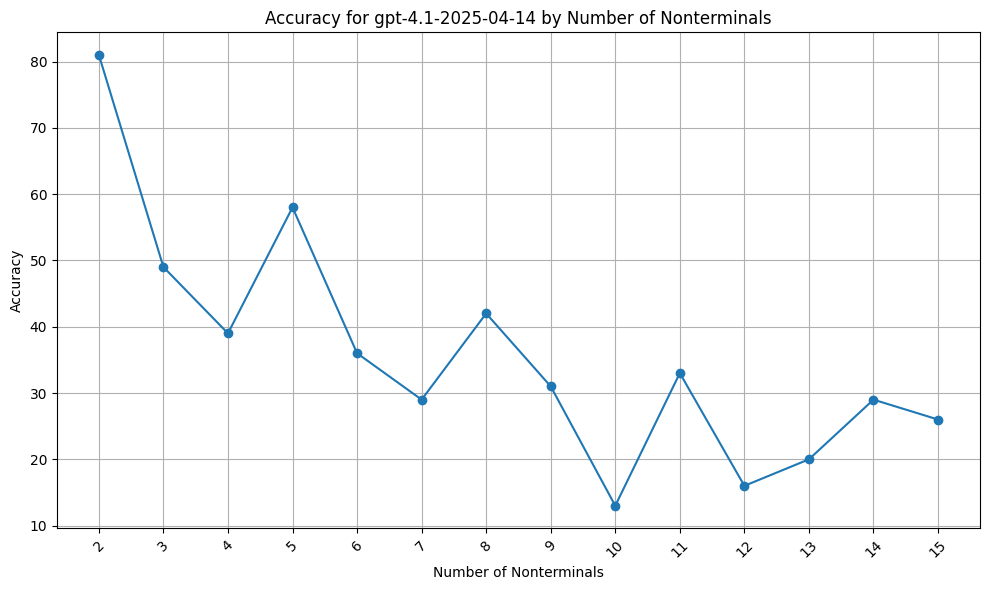

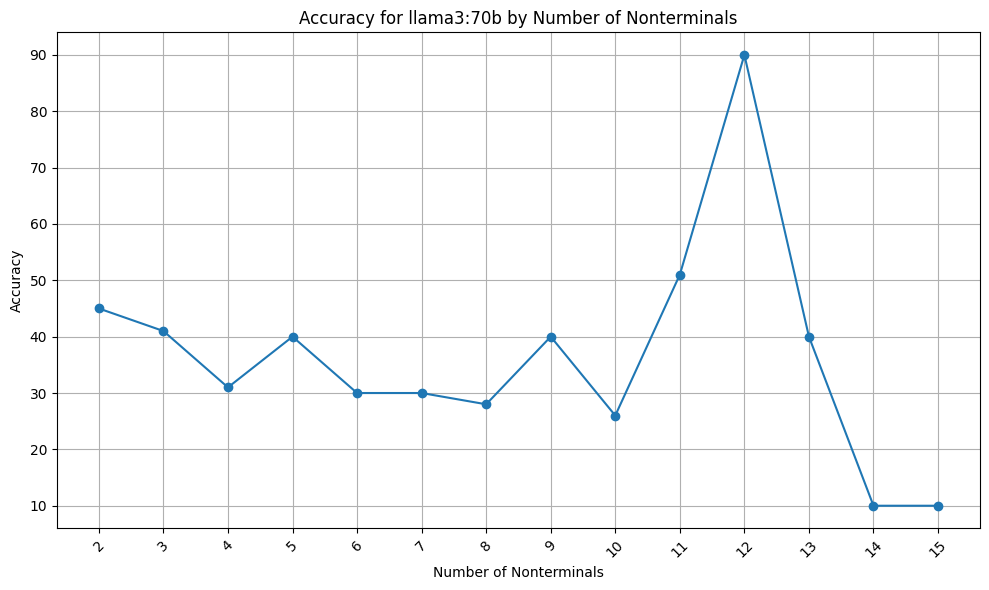

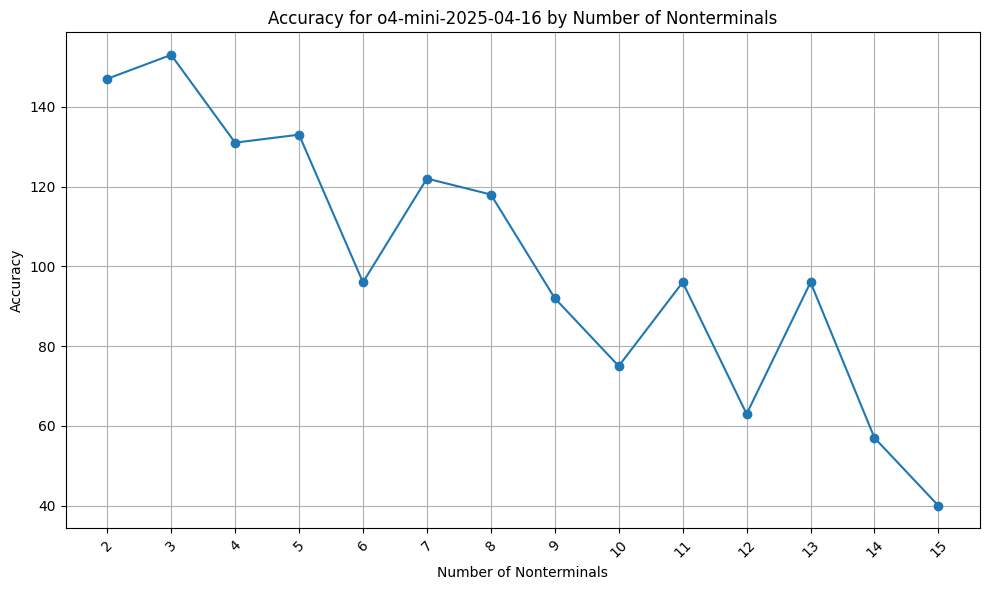

In [11]:
import matplotlib.pyplot as plt

df_cases['num_nonterminals'] = pd.to_numeric(df_cases['num_nonterminals'], errors='coerce')
df_cases = df_cases.dropna(subset=['num_nonterminals'])
df_cases['num_nonterminals'] = df_cases['num_nonterminals'].astype(int)

all_num_nts = sorted(df_cases['num_nonterminals'].unique())
models = df_nt_correctes['model'].unique()

for model in models:
    df_model_raw = df_nt_correctes[df_nt_correctes['model'] == model]
    df_model = pd.DataFrame({'num_nonterminals': all_num_nts})
    df_model = df_model.merge(df_model_raw[['num_nonterminals', 'accuracy']], on='num_nonterminals', how='left')
    df_model['accuracy'] = df_model['accuracy'].fillna(0).astype(int)
    
    plt.figure(figsize=(10, 6))
    plt.plot(df_model['num_nonterminals'], df_model['accuracy'], marker='o', linestyle='-')


    plt.title(f'Accuracy for {model} by Number of Nonterminals')
    plt.xlabel('Number of Nonterminals')
    plt.ylabel('Accuracy')
    plt.xticks(all_num_nts, rotation=45)
    # plt.ylim(0, 100)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

/var/folders/4p/mcvjxqjj0f32176nf_3wv1gc0000gt/T/ipykernel_40172/169938833.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_mut, x='num_nonterminals', y='mutation_depth', palette='tab10')


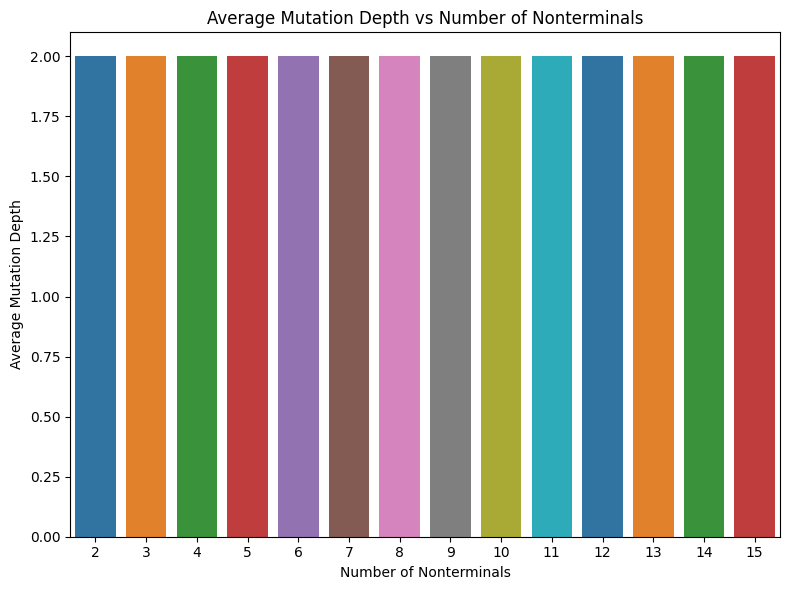

In [12]:
# Bar plot of average mutation_depth vs num_nonterminals
avg_mut = df_cases.groupby('num_nonterminals')['mutation_depth'].mean().reset_index()
plt.figure(figsize=(8, 6))
sns.barplot(data=avg_mut, x='num_nonterminals', y='mutation_depth', palette='tab10')
plt.xlabel('Number of Nonterminals')
plt.ylabel('Average Mutation Depth')
plt.title('Average Mutation Depth vs Number of Nonterminals')
plt.tight_layout()


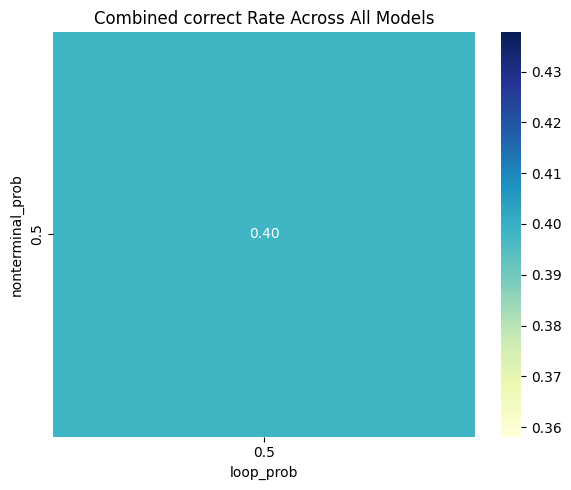

In [13]:
# Combined heatmap of correct-rate across all models by nonterminal_prob and loop_prob
records = []
for db_path in sources_dbs:
    conn = sqlite3.connect(db_path)
    df_res = pd.read_sql(
        'SELECT nonterminal_prob, loop_prob, correct FROM repair_results', conn
    )
    conn.close()
    df_res['model'] = os.path.basename(db_path)
    records.append(df_res)

df_all = pd.concat(records, ignore_index=True)

totals = df_all.groupby(['nonterminal_prob','loop_prob']).size().rename('total')
successes= df_all[df_all['correct'] == 1].groupby(['nonterminal_prob','loop_prob']).size().rename('success')
df_rate = pd.concat([totals, successes], axis=1).fillna(0)
df_rate['rate'] = df_rate['success'] / df_rate['total']
pivot = df_rate['rate'].unstack(level='loop_prob')

plt.figure(figsize=(6, 5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Combined correct Rate Across All Models')
plt.xlabel('loop_prob')
plt.ylabel('nonterminal_prob')
plt.tight_layout()


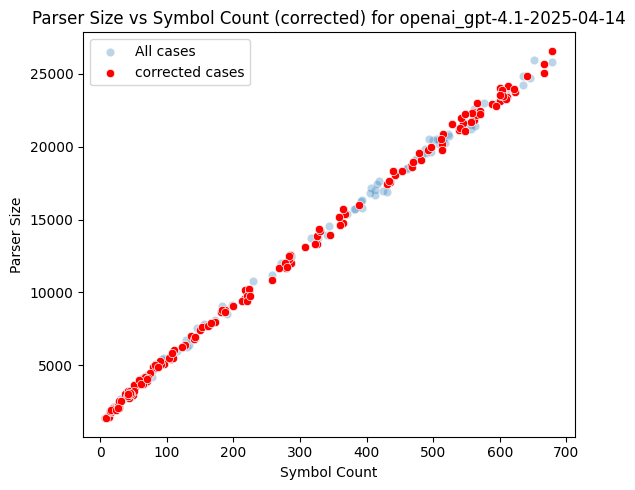

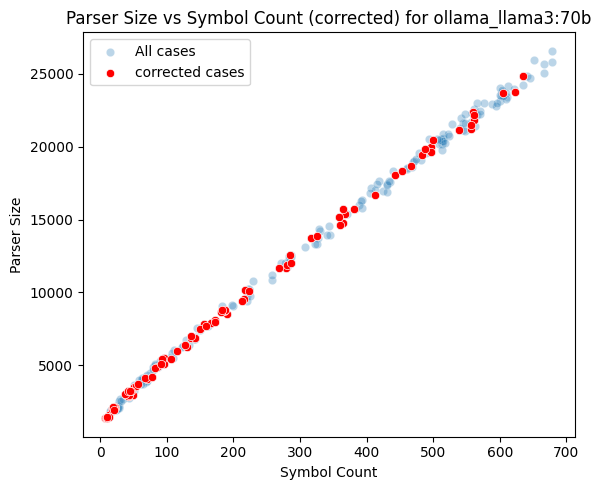

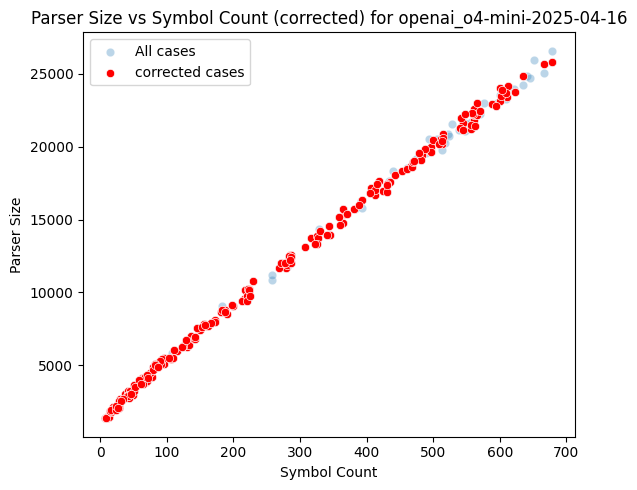

In [14]:
# Scatter plot of parser_size vs corrupted_symbol_count, highlighting corrected cases per model
for db_path in sources_dbs:
    model = os.path.basename(db_path).removeprefix('repair_results_').removesuffix(f'_targets{database_version}.db')
    conn = sqlite3.connect(db_path)
    df_res = pd.read_sql(
        'SELECT case_id, correct FROM repair_results', conn
    )
    conn.close()
    corrected = df_res[df_res['correct'] == 1]['case_id']
    plt.figure(figsize=(6, 5))
    sns.scatterplot(data=df_cases, x='corrupted_symbol_count', y='parser_size', alpha=0.3, label='All cases')
    sns.scatterplot(data=df_cases[df_cases['puzzle_id'].isin(corrected)], 
                    x='corrupted_symbol_count', y='parser_size', color='red', label='corrected cases')
    plt.title(f'Parser Size vs Symbol Count (corrected) for {model}')
    plt.xlabel('Symbol Count')
    plt.ylabel('Parser Size')
    plt.legend()
    plt.tight_layout()


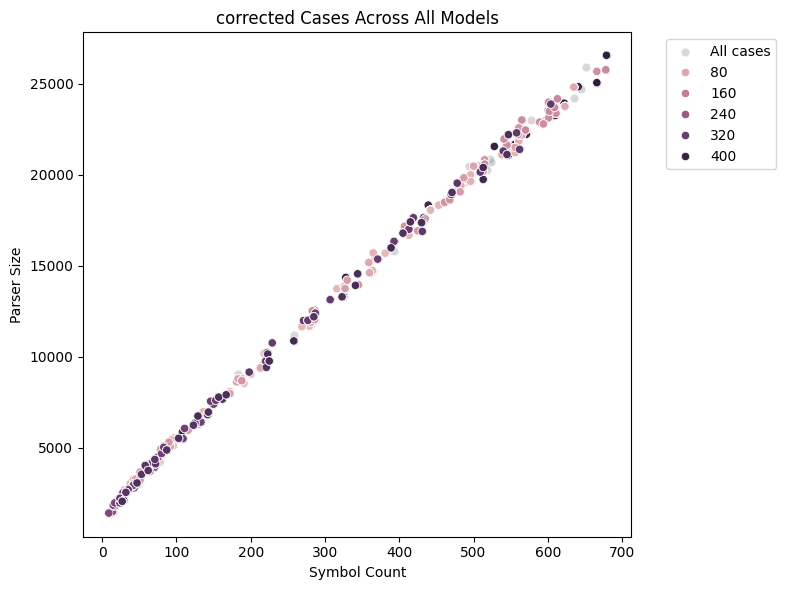

In [15]:
# Combined scatter plot of corrected cases across all models
records = []
for db_path in sources_dbs:
    model = os.path.basename(db_path).removeprefix('repair_results_').removesuffix(f'_targets{database_version}.db')
    conn = sqlite3.connect(db_path)
    df_res = pd.read_sql('SELECT case_id, puzzle_id, correct, total_tokens FROM repair_results', conn)
    # Merge using cases.id (puzzle_id) mapping to source puzzle.id
    df_tmp = df_res[df_res['correct'] == 1].merge(df_cases, left_on='case_id', right_on='puzzle_id')
    df_tmp['model'] = model
    records.append(df_tmp)
    conn.close()

df_corrected_all = pd.concat(records, ignore_index=True)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_cases, x='corrupted_symbol_count', y='parser_size', color='gray', alpha=0.3, label='All cases')
sns.scatterplot(data=df_corrected_all, x='corrupted_symbol_count', y='parser_size', hue='puzzle_id_x')
plt.xlabel('Symbol Count')
plt.ylabel('Parser Size')
plt.title('corrected Cases Across All Models')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()


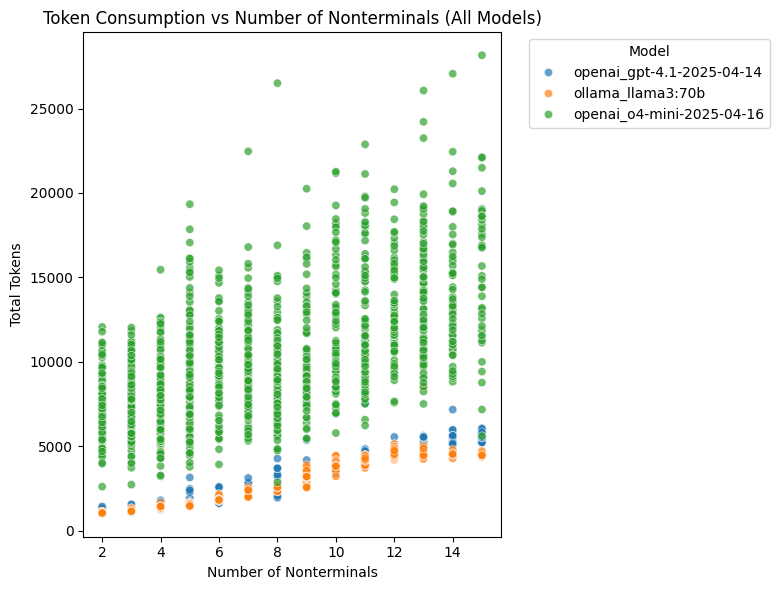

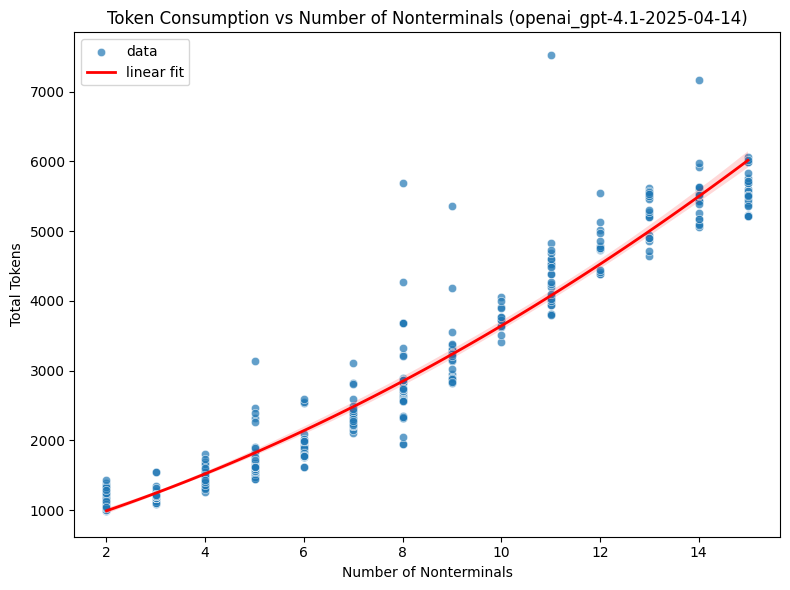

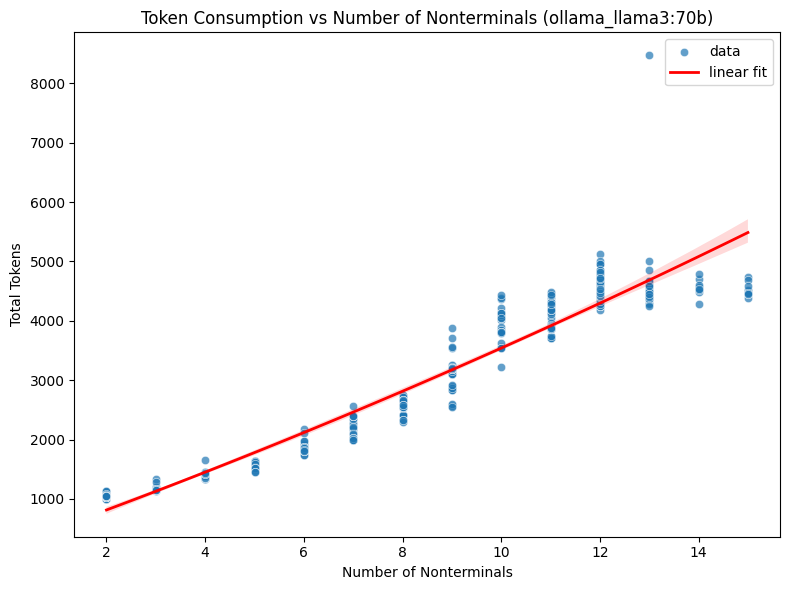

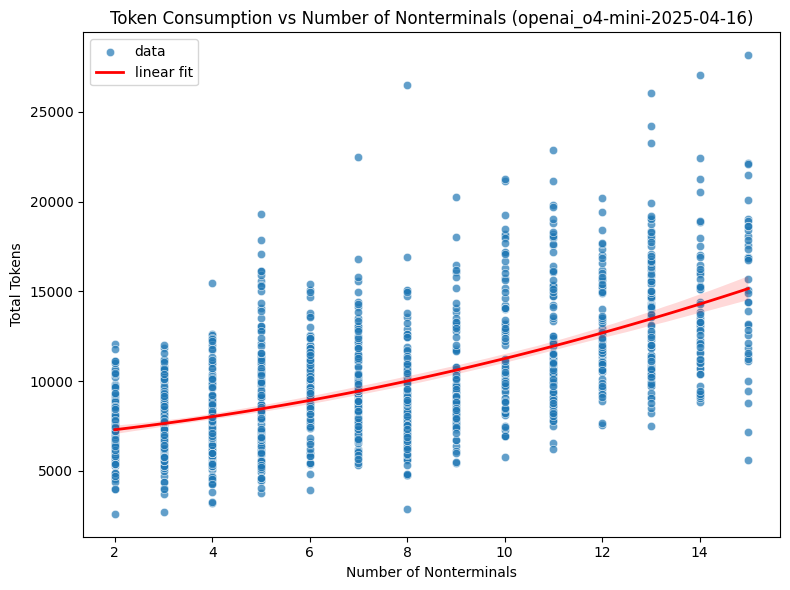

In [16]:
# Scatter plot of token consumption vs number of nonterminals across all corrected cases
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_corrected_all, x='num_nonterminals', y='total_tokens', hue='model', alpha=0.7)
plt.xlabel('Number of Nonterminals')
plt.ylabel('Total Tokens')
plt.title('Token Consumption vs Number of Nonterminals (All Models)')
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Individual model plots with linear fit
for model in df_corrected_all['model'].unique():
    df_mod = df_corrected_all[df_corrected_all['model'] == model]
    plt.figure(figsize=(8, 6))

    sns.scatterplot(
        data=df_mod,
        x='num_nonterminals',
        y='total_tokens',
        color='C0',
        alpha=0.7,
        label='data'
    )
    sns.regplot(
        data=df_mod,
        x='num_nonterminals',
        y='total_tokens',
        scatter=False,      # 不画散点
        line_kws={'color': 'red', 'lw': 2},
        label='linear fit',
        order=2
    )

    plt.xlabel('Number of Nonterminals')
    plt.ylabel('Total Tokens')
    plt.title(f'Token Consumption vs Number of Nonterminals ({model})')
    plt.legend()
    plt.tight_layout()
    plt.show()


/Users/jack/Grammar_bench/venv/lib/python3.12/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/Users/jack/Grammar_bench/venv/lib/python3.12/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/Users/jack/Grammar_bench/venv/lib/python3.12/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/Users/jack/Grammar_bench/venv/lib/python3.12/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/Users/jack/Grammar_bench/venv/lib/python3.12/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/Users/jack/Grammar_bench/venv/lib/python3.12/site-packages/seabo

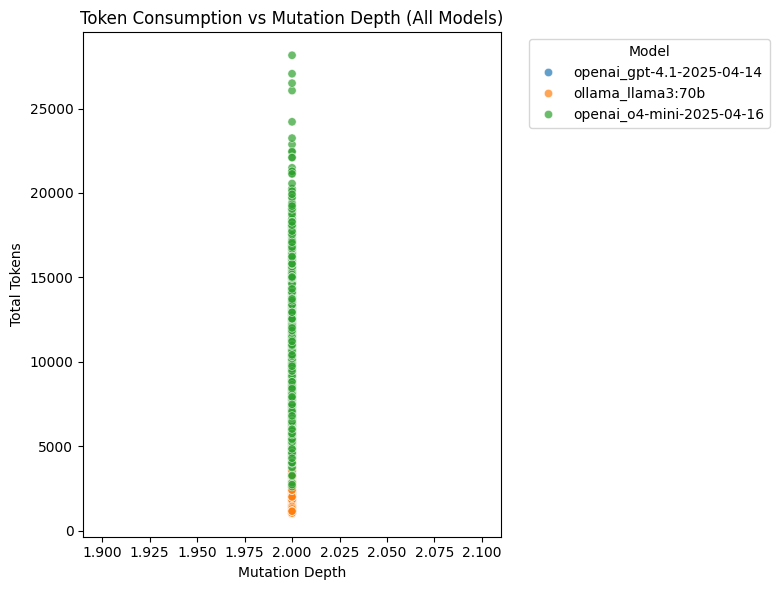

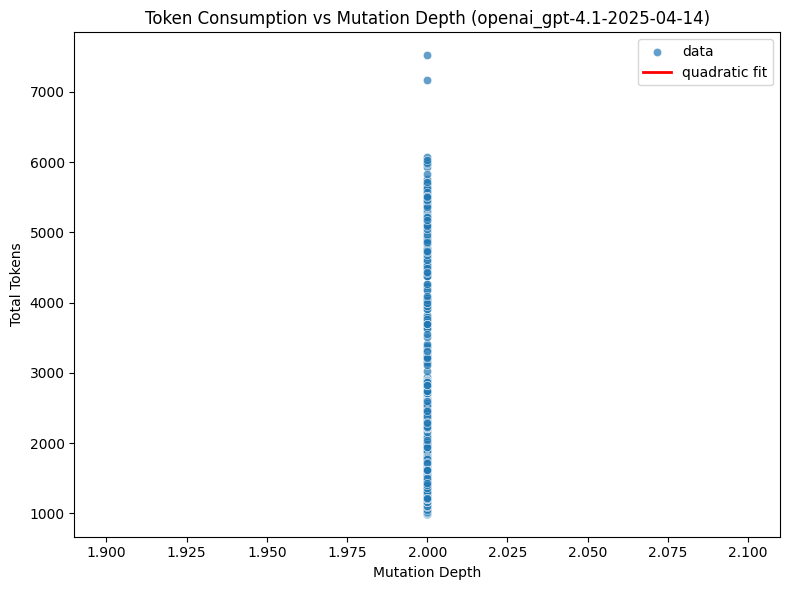

/Users/jack/Grammar_bench/venv/lib/python3.12/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/Users/jack/Grammar_bench/venv/lib/python3.12/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/Users/jack/Grammar_bench/venv/lib/python3.12/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/Users/jack/Grammar_bench/venv/lib/python3.12/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/Users/jack/Grammar_bench/venv/lib/python3.12/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/Users/jack/Grammar_bench/venv/lib/python3.12/site-packages/seabo

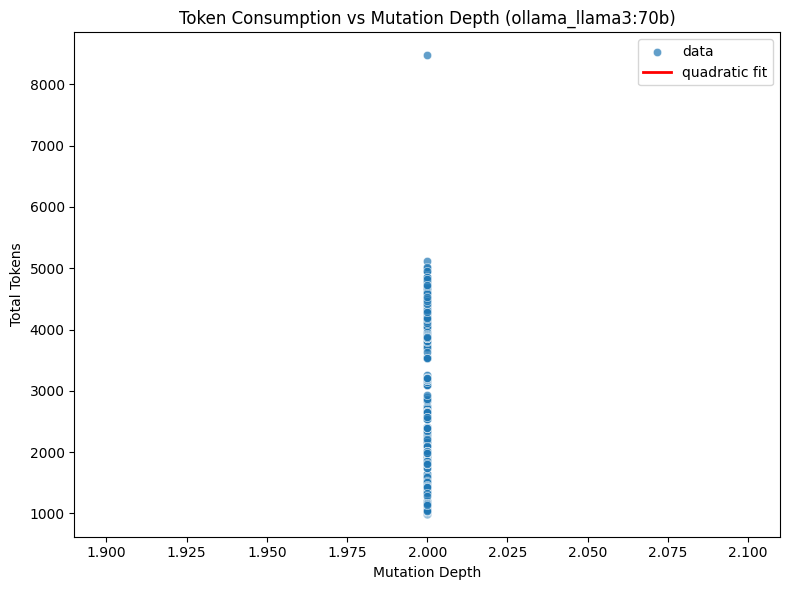

/Users/jack/Grammar_bench/venv/lib/python3.12/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/Users/jack/Grammar_bench/venv/lib/python3.12/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/Users/jack/Grammar_bench/venv/lib/python3.12/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/Users/jack/Grammar_bench/venv/lib/python3.12/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/Users/jack/Grammar_bench/venv/lib/python3.12/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/Users/jack/Grammar_bench/venv/lib/python3.12/site-packages/seabo

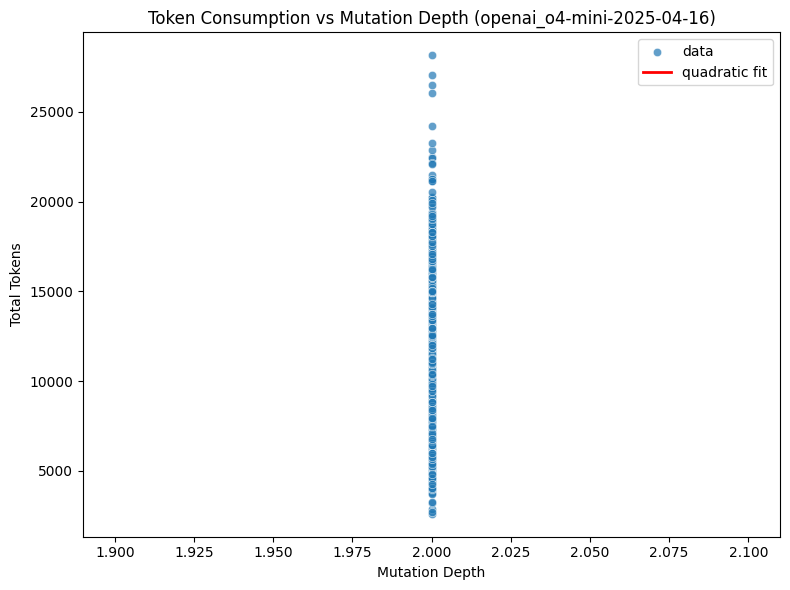

In [17]:
# Scatter plot of token consumption vs mutation depth across all corrected cases
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_corrected_all, x='mutation_depth', y='total_tokens', hue='model', alpha=0.7)
plt.xlabel('Mutation Depth')
plt.ylabel('Total Tokens')
plt.title('Token Consumption vs Mutation Depth (All Models)')
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Individual model plots with quadratic fit
for model in df_corrected_all['model'].unique():
    df_mod = df_corrected_all[df_corrected_all['model'] == model]
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df_mod, x='mutation_depth', y='total_tokens', color='C0', alpha=0.7, label='data')
    sns.regplot(data=df_mod, x='mutation_depth', y='total_tokens', scatter=False, line_kws={'color': 'red', 'lw': 2}, label='quadratic fit', order=2)
    plt.xlabel('Mutation Depth')
    plt.ylabel('Total Tokens')
    plt.title(f'Token Consumption vs Mutation Depth ({model})')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [18]:
# Table of corrected cases counts by mutation_depth for each model
records = []
for db_path in sources_dbs:
    model = os.path.basename(db_path).removeprefix('repair_results_').removesuffix(f'_targets{database_version}.db')
    conn = sqlite3.connect(db_path)
    df_res = pd.read_sql('SELECT case_id, correct FROM repair_results', conn)
    conn.close()
    df_ok = df_res[df_res['correct'] == 1].merge(df_cases[['puzzle_id','mutation_depth']], left_on='case_id', right_on='puzzle_id')
    counts = df_ok['mutation_depth'].value_counts().sort_index()
    for depth, cnt in counts.items():
        records.append({'model': model, 'mutation_depth': depth, 'accuracy': cnt})

df_mut_counts = pd.DataFrame(records)
pivot_mut = df_mut_counts.pivot(index='mutation_depth', columns='model', values='accuracy').fillna(0).astype(int)
print(pivot_mut)


model           ollama_llama3:70b  openai_gpt-4.1-2025-04-14  \
mutation_depth                                                 
2                             512                        502   

model           openai_o4-mini-2025-04-16  
mutation_depth                             
2                                    1419  


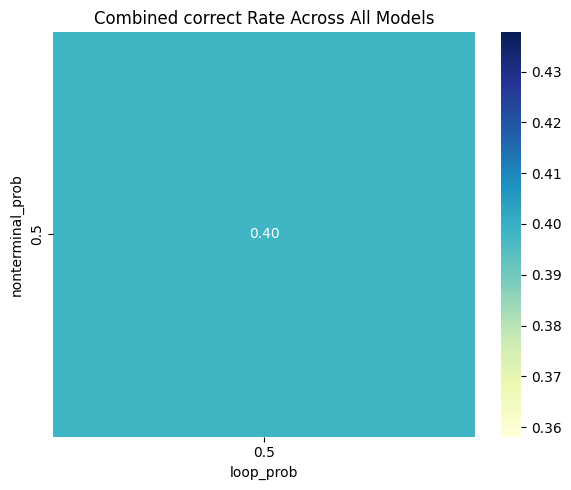

In [19]:
records = []
for db_path in sources_dbs:
    conn = sqlite3.connect(db_path)
    df_res = pd.read_sql(
        'SELECT nonterminal_prob, loop_prob, correct FROM repair_results', conn
    )
    conn.close()
    df_res['model'] = os.path.basename(db_path)
    records.append(df_res)

df_all = pd.concat(records, ignore_index=True)

# compute total & successful counts per (nonterminal_prob, loop_prob)
totals    = df_all.groupby(['nonterminal_prob','loop_prob']).size().rename('total')
successes = df_all[df_all['correct'] == 1] \
                    .groupby(['nonterminal_prob','loop_prob']).size().rename('success')
df_rate   = pd.concat([totals, successes],
axis=1).fillna(0)
df_rate['rate'] = df_rate['success'] / df_rate['total']

# pivot into heatmap-friendly form
pivot = df_rate['rate'].unstack(level='loop_prob')

# plot
plt.figure(figsize=(6, 5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Combined correct Rate Across All Models')
plt.xlabel('loop_prob')
plt.ylabel('nonterminal_prob')
plt.tight_layout()

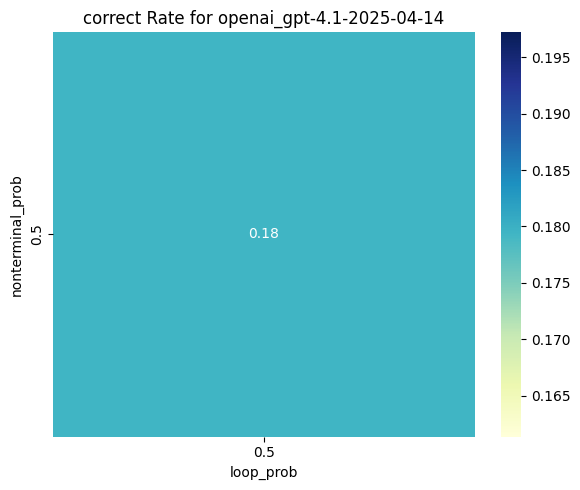

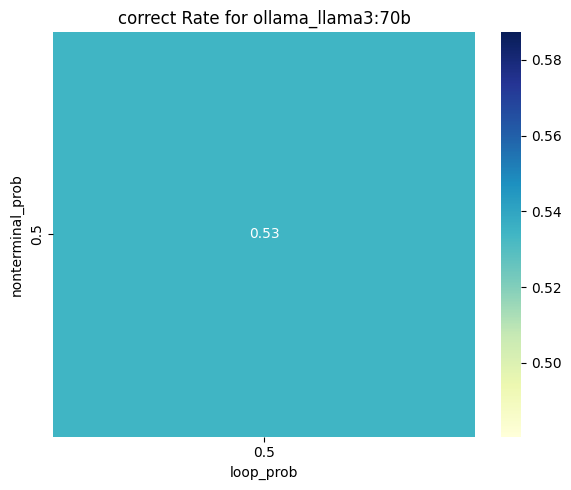

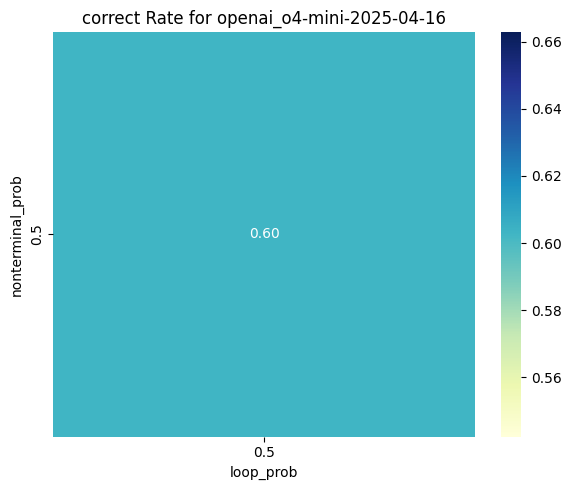

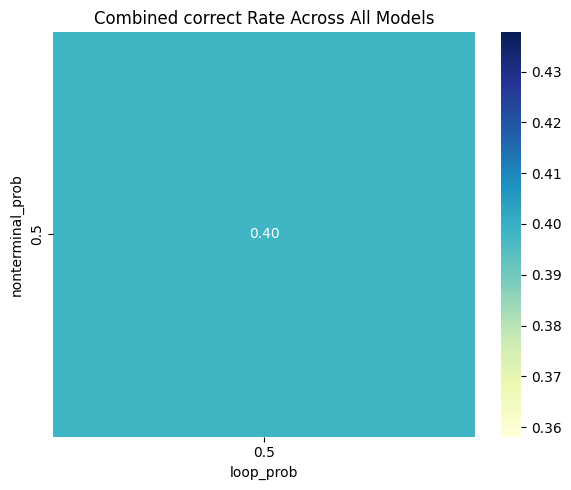

In [20]:
for db_path in sources_dbs:
        model = os.path.basename(db_path).removeprefix('repair_results_').removesuffix(f'_targets{database_version}.db')
        conn = sqlite3.connect(db_path)
        df_res = pd.read_sql(
            'SELECT nonterminal_prob, loop_prob, correct FROM repair_results',
            conn
        )
        conn.close()

        # Compute success rate per (nonterminal_prob, loop_prob)
        totals   = df_res.groupby(['nonterminal_prob','loop_prob']).size().rename('total')
        successes= df_res[df_res['correct'] == 1] \
                        .groupby(['nonterminal_prob','loop_prob']).size().rename('success')
        df_rate  = pd.concat([totals, successes], axis=1).fillna(0)
        df_rate['rate'] = df_rate['success'] / df_rate['total']

        # Pivot for heatmap
        pivot = df_rate['rate'].unstack(level='loop_prob')

        plt.figure(figsize=(6, 5))
        sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlGnBu')
        plt.title(f'correct Rate for {model}')
        plt.xlabel('loop_prob')
        plt.ylabel('nonterminal_prob')
        plt.tight_layout()

# Combined heatmap of correct-rate across all models by nonterminal_prob and loop_prob
records = []
for db_path in sources_dbs:
    conn = sqlite3.connect(db_path)
    df_res = pd.read_sql(
        'SELECT nonterminal_prob, loop_prob, correct FROM repair_results',
        conn
    )
    conn.close()
    df_res['model'] = os.path.basename(db_path)
    records.append(df_res)

df_all = pd.concat(records, ignore_index=True)

# Compute aggregated success rate
totals   = df_all.groupby(['nonterminal_prob','loop_prob']).size().rename('total')
successes= df_all[df_all['correct'] == 1] \
                .groupby(['nonterminal_prob','loop_prob']).size().rename('success')
df_rate  = pd.concat([totals, successes], axis=1).fillna(0)
df_rate['rate'] = df_rate['success'] / df_rate['total']

# Pivot for combined heatmap
pivot = df_rate['rate'].unstack(level='loop_prob')

plt.figure(figsize=(6, 5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Combined correct Rate Across All Models')
plt.xlabel('loop_prob')
plt.ylabel('nonterminal_prob')
plt.tight_layout()


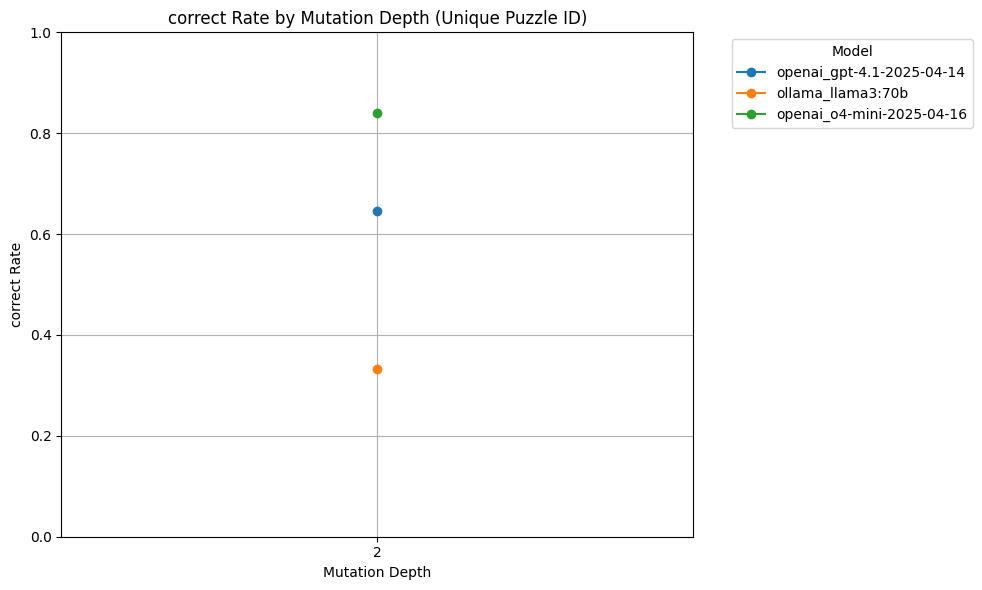

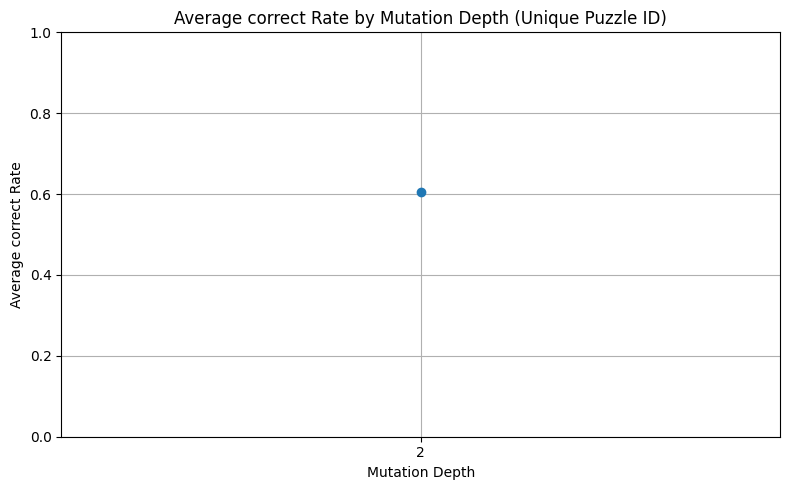

In [21]:
import matplotlib.pyplot as plt

# Step 1: 统计每个模型成功修复的 puzzle（按 mutation_depth）
records = []
for db_path in sources_dbs:
    model = os.path.basename(db_path).removeprefix('repair_results_').removesuffix(f'_targets{database_version}.db')
    conn = sqlite3.connect(db_path)
    try:
        df_res = pd.read_sql("SELECT case_id, correct FROM repair_results", conn)
    except pd.io.sql.DatabaseError:
        conn.close()
        continue
    conn.close()

    # Merge on puzzle_id (cases.id) and case_id
    df_merged = df_res[df_res['correct'] == 1].merge(
        df_cases[['puzzle_id', 'mutation_depth']],
        left_on='case_id', right_on='puzzle_id'
    )

    # 按 puzzle_id 去重，避免重复计入多个 case
    df_unique = df_merged.drop_duplicates(subset='puzzle_id')
    counts = df_unique['mutation_depth'].value_counts().sort_index()
    for depth, cnt in counts.items():
        records.append({'model': model, 'mutation_depth': depth, 'correct_count': cnt})

df_counts = pd.DataFrame(records)

# Step 2: 计算 total_cases（按 puzzle_id 去重）
df_unique_puzzles = df_cases.drop_duplicates(subset='puzzle_id')
total_cases = df_unique_puzzles['mutation_depth'].value_counts().sort_index().to_dict()
all_depths = sorted(total_cases.keys())
all_models = df_counts['model'].unique()

# Step 3: 构造完整的 correct_rate 表格
full_records = []
for model in all_models:
    model_df = df_counts[df_counts['model'] == model].set_index('mutation_depth')['correct_count'].to_dict()
    for depth in all_depths:
        correct_count = model_df.get(depth, 0)
        total = total_cases.get(depth, 0)
        rate = correct_count / total if total > 0 else 0
        full_records.append({'model': model, 'mutation_depth': depth, 'correct_rate': rate})

df_rates = pd.DataFrame(full_records)

# Step 4: 绘图（每个模型折线）
plt.figure(figsize=(10, 6))
for model in df_rates['model'].unique():
    df_model = df_rates[df_rates['model'] == model].sort_values('mutation_depth')
    plt.plot(df_model['mutation_depth'], df_model['correct_rate'], marker='o', label=model)

plt.xlabel('Mutation Depth')
plt.ylabel('correct Rate')
plt.title('correct Rate by Mutation Depth (Unique Puzzle ID)')
plt.xticks(all_depths)
plt.ylim(0, 1)
plt.grid(True)
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Step 5: 绘图（所有模型的平均宽松准确率）
df_avg = df_rates.groupby('mutation_depth')['correct_rate'].mean().reset_index()

plt.figure(figsize=(8, 5))
plt.plot(df_avg['mutation_depth'], df_avg['correct_rate'], marker='o', linestyle='-')
plt.xlabel('Mutation Depth')
plt.ylabel('Average correct Rate')
plt.title('Average correct Rate by Mutation Depth (Unique Puzzle ID)')
plt.xticks(all_depths)
plt.ylim(0, 1)
plt.grid(True)
plt.tight_layout()
plt.show()

Pass@K

In [22]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

db_paths = [
 "repair_results_gemini_gemini-2.5-flash_targets6.db",
"repair_results_ollama_llama3:70b_targets6.db",
"repair_results_openai_gpt-4.1-2025-04-14_targets6.db"
]
ks = list(range(1, 6))
records = []

for db_path in db_paths:
    model = os.path.splitext(os.path.basename(db_path))[0]
    conn = sqlite3.connect(db_path)

    # Skip if there's no repair_results table
    existing = pd.read_sql(
        "SELECT name FROM sqlite_master WHERE type='table' AND name='repair_results'",
        conn
    )
    if existing.empty:
        print(f"{db_path} has no repair_results table, skipping…")
        conn.close()
        continue

    # Check if 'sample' column exists
    info = pd.read_sql("PRAGMA table_info(repair_results)", conn)
    has_sample = 'sample' in info['name'].tolist()

    # Read required columns
    cols = "puzzle_id, correct" + (", sample" if has_sample else "")
    df = pd.read_sql(f"SELECT {cols} FROM repair_results", conn)
    conn.close()

    # If no sample column, assign sample numbers by puzzle_id occurrence order
    if not has_sample:
        df['sample'] = df.groupby('puzzle_id').cumcount() + 1

    total = df['puzzle_id'].nunique()
    for k in ks:
        df_k = df[df['sample'] <= k]
        # For each puzzle_id, if any of the first k attempts corrected it, count as passed
        passed = df_k.groupby('puzzle_id')['correct'].max().sum()
        rate = passed / total
        records.append({"model": model, "k": k, "rate": rate})

df_pass_k = pd.DataFrame(records)

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_pass_k, x='k', y='rate', hue='model', marker='o')
plt.xticks(ks, rotation=45)
plt.xlabel('k (max attempts)')
plt.ylabel('Pass@k Rate')
plt.title('Pass@k Rate per Model (from targets4 DB, sample by puzzle_id order)')
plt.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

repair_results_gemini_gemini-2.5-flash_targets6.db has no repair_results table, skipping…
repair_results_ollama_llama3:70b_targets6.db has no repair_results table, skipping…
repair_results_openai_gpt-4.1-2025-04-14_targets6.db has no repair_results table, skipping…


ValueError: Could not interpret value `k` for `x`. An entry with this name does not appear in `data`.

<Figure size 1000x600 with 0 Axes>